In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

processed_dir = Path("data/02_processed")

print("Loading Silver Layer...")
all_files = list(processed_dir.glob("metrics_*.parquet"))
df_master = pd.concat((pd.read_parquet(f) for f in all_files), ignore_index=True)

# --- THE DATETIME CONVERSION ---
year_str = df_master['year'].astype(int).astype(str)
day_str = df_master['day_of_year'].astype(int).astype(str).str.zfill(3)

df_master['snapshot_date'] = pd.to_datetime(year_str + day_str, format='%Y%j')

# Sort chronologically and by PageRank
df_master = df_master.sort_values(by=['snapshot_date', 'pagerank'], ascending=[True, False]).reset_index(drop=True)

print(f"✅ Gold Layer built! Total clean historical records: {len(df_master)}")
display(df_master.head())

Loading Silver Layer...
✅ Gold Layer built! Total clean historical records: 27782


,node_name,year,day_of_year,in_degree,out_degree,pagerank,betweenness,is_in_bcc,snapshot_date
0,kemal,2018,148,35,2,0.026951,0.000794,True,2018-05-28
1,minitest,2018,148,17,0,0.024772,0.000000,True,2018-05-28
2,db,2018,148,17,0,0.023859,0.000000,True,2018-05-28
3,radix,2018,148,7,0,0.018899,0.000000,True,2018-05-28
4,spec2,2018,148,18,0,0.015100,0.000000,True,2018-05-28


Aggregating historical growth...


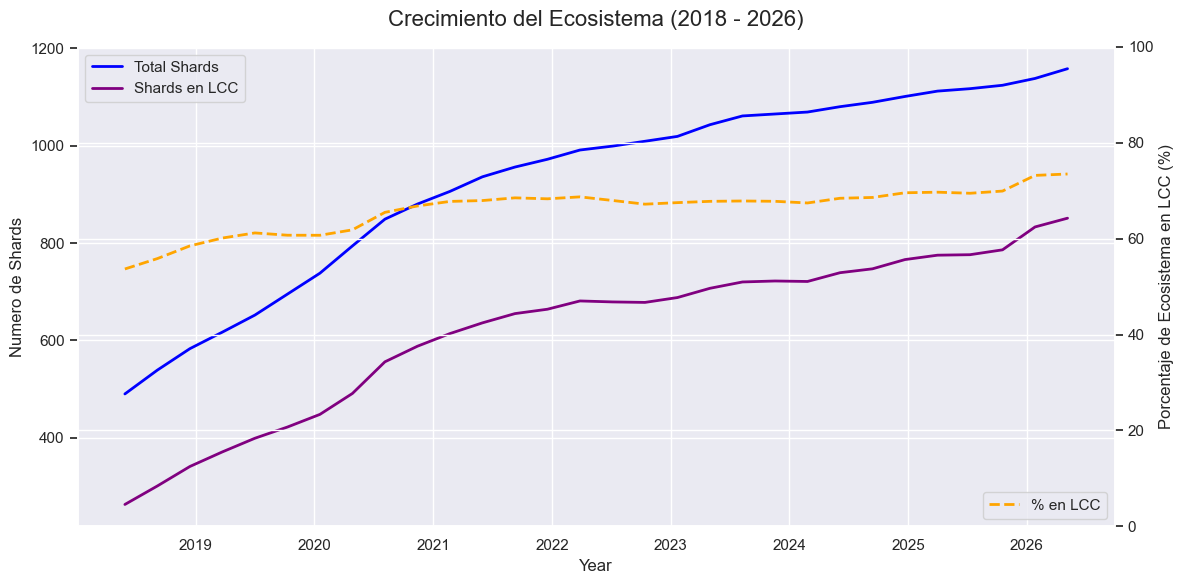

In [12]:
print("Aggregating historical growth...")

# Group by the snapshot date to get daily totals
growth_df = df_master.groupby('snapshot_date').agg(
    total_shards=('node_name', 'count'),
    bcc_size=('is_in_bcc', 'sum')
).reset_index()

# Calculate the BCC percentage
growth_df['bcc_percentage'] = (growth_df['bcc_size'] / growth_df['total_shards']) * 100

# Setup the chart
sns.set_theme(style="darkgrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Absolute Numbers (Left Y-Axis)
sns.lineplot(data=growth_df, x='snapshot_date', y='total_shards', 
             ax=ax1, color='blue', linewidth=2, label='Total Shards')
sns.lineplot(data=growth_df, x='snapshot_date', y='bcc_size', 
             ax=ax1, color='purple', linewidth=2, label='Shards en LCC')

ax1.set_title("Crecimiento del Ecosistema (2018 - 2026)", fontsize=16, pad=15)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Numero de Shards", fontsize=12)
ax1.legend(loc='upper left')

# Plot 2: BCC Percentage (Right Y-Axis)
ax2 = ax1.twinx()
sns.lineplot(data=growth_df, x='snapshot_date', y='bcc_percentage', 
             ax=ax2, color='orange', linewidth=2, linestyle='--', label='% en LCC')

ax2.set_ylabel("Porcentaje de Ecosistema en LCC (%)", fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path

# Create the Gold directory if it doesn't exist
gold_dir = Path("data/03_gold")
gold_dir.mkdir(parents=True, exist_ok=True)

# Save the master dataframe
output_path = gold_dir / "ecosystem_master.parquet"
df_master.to_parquet(output_path, index=False)

print(f"✅ Master dataset saved to {output_path}")

✅ Master dataset saved to data/03_gold/ecosystem_master.parquet


In [14]:
import pandas as pd
from pathlib import Path
from datetime import datetime

raw_dir = Path("data/01_raw")
gold_dir = Path("data/03_gold")
gold_dir.mkdir(parents=True, exist_ok=True)

print("1. Indexing available Raw data...")
available_snapshots = {}

# Map all raw folders to real datetime objects
for edge_path in raw_dir.rglob("edges.parquet"):
    year_val = edge_path.parts[-3].split('=')[1]
    day_val = edge_path.parts[-2].split('=')[1]
    
    # Convert Year and Day-of-Year to a standard datetime
    dt = datetime.strptime(f"{year_val}-{day_val}", "%Y-%j")
    available_snapshots[dt] = edge_path

# Sort chronologically so we can search them
sorted_dates = sorted(available_snapshots.keys())
print(f"   -> Found {len(sorted_dates)} total raw snapshots.\n")

print("2. Materializing 30 target slices into Gold Layer...")
anchor_date = "2026-05-06"
target_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")

for target in target_dates:
    target_key = target.strftime('%Y-%m-%d')
    
    # Find the most recent raw snapshot that occurred ON or BEFORE our target date
    valid_dates = [d for d in sorted_dates if d <= target]
    
    if not valid_dates:
        print(f"⚠️ {target_key}: Skipped (No raw data exists prior to this date)")
        continue
        
    closest_date = valid_dates[-1]
    edge_path = available_snapshots[closest_date]
    
    # Extract year/day strings to find the matching Silver metrics
    year_val = edge_path.parts[-3].split('=')[1]
    day_val = edge_path.parts[-2].split('=')[1]
    
    try:
        edges_df = pd.read_parquet(edge_path)
        metrics_df = pd.read_parquet(Path(f"data/02_processed/metrics_{year_val}_{day_val}.parquet"))
        
        # Save them into Gold using our clean YYYY-MM-DD target key
        edges_df.to_parquet(gold_dir / f"gold_edges_{target_key}.parquet", index=False)
        metrics_df.to_parquet(gold_dir / f"gold_nodes_{target_key}.parquet", index=False)
        print(f"✅ {target_key}: Materialized (using data from {closest_date.strftime('%Y-%m-%d')})")
        
    except FileNotFoundError:
        print(f"❌ {target_key}: Failed (Silver metrics missing for {year_val}-{day_val})")

print("\n🏁 Gold Layer is fully populated!")

1. Indexing available Raw data...
   -> Found 30 total raw snapshots.

2. Materializing 30 target slices into Gold Layer...
✅ 2018-05-28: Materialized (using data from 2018-05-28)
✅ 2018-09-05: Materialized (using data from 2018-09-05)
✅ 2018-12-14: Materialized (using data from 2018-12-14)
✅ 2019-03-24: Materialized (using data from 2019-03-24)
✅ 2019-07-02: Materialized (using data from 2019-07-02)
✅ 2019-10-10: Materialized (using data from 2019-10-10)
✅ 2020-01-18: Materialized (using data from 2020-01-18)
✅ 2020-04-27: Materialized (using data from 2020-04-27)
✅ 2020-08-05: Materialized (using data from 2020-08-05)
✅ 2020-11-13: Materialized (using data from 2020-11-13)
✅ 2021-02-21: Materialized (using data from 2021-02-21)
✅ 2021-06-01: Materialized (using data from 2021-06-01)
✅ 2021-09-09: Materialized (using data from 2021-09-09)
✅ 2021-12-18: Materialized (using data from 2021-12-18)
✅ 2022-03-28: Materialized (using data from 2022-03-28)
✅ 2022-07-06: Materialized (using da

# Ajuste a distribucion de potencia

In [17]:
import pandas as pd
import networkx as nx
import numpy as np
from scipy.stats import linregress
from pathlib import Path

gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"

# 1. Generate the 30 dates, then slice every 5th date going backwards
all_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")
# Reverse the list and take every 5th element
target_dates = all_dates[::-5] 

print(f"Running topology analysis for {len(target_dates)} sampled snapshots...")
results = []

for ts in target_dates:
    snapshot_key = ts.strftime('%Y-%m-%d')
    edge_file = gold_dir / f"gold_edges_{snapshot_key}.parquet"
    
    if not edge_file.exists():
        print(f"  [!] Skipping {snapshot_key}: No data found.")
        continue
        
    print(f"  -> Analyzing {snapshot_key}...")
    edges_df = pd.read_parquet(edge_file)
    G = nx.from_pandas_edgelist(edges_df, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    if G.number_of_nodes() == 0:
        continue

    # --- A. Power Law Fit (In-Degree) ---
    in_degrees = [d for n, d in G.in_degree() if d > 0]
    if len(in_degrees) > 2:
        degree_counts = pd.Series(in_degrees).value_counts().sort_index()
        log_k = np.log10(degree_counts.index.values)
        log_P_k = np.log10(degree_counts.values)
        slope, _, r_val, _, _ = linregress(log_k, log_P_k)
        gamma = -slope
        r_squared = r_val ** 2
    else:
        gamma, r_squared = None, None

    # --- B. Empirical Topology (No more LCC cropping) ---
    G_und = G.to_undirected()
    N = G_und.number_of_nodes()
    M = G_und.number_of_edges()
    
    if N < 10:
        continue
        
    k_avg = 2 * M / N
    emp_C = nx.average_clustering(G_und)
    
    # REPLACED: average_shortest_path_length with global_efficiency
    emp_E = nx.global_efficiency(G_und)

    # --- C. Simulated Models ---
    # 1. Random (Erdős-Rényi)
    p_er = min(1.0, k_avg / (N - 1))
    G_er = nx.erdos_renyi_graph(n=N, p=p_er, seed=42)
    er_C = nx.average_clustering(G_er)
    er_E = nx.global_efficiency(G_er)

    # 2. Small World (Watts-Strogatz)
    k_ws = max(2, int(round(k_avg))) 
    G_ws = nx.watts_strogatz_graph(n=N, k=k_ws, p=0.1, seed=42)
    ws_C = nx.average_clustering(G_ws)
    ws_E = nx.global_efficiency(G_ws)

    # 3. Scale-Free (Barabási-Albert)
    m_ba = max(1, int(round(k_avg / 2)))
    G_ba = nx.barabasi_albert_graph(n=N, m=m_ba, seed=42)
    ba_C = nx.average_clustering(G_ba)
    ba_E = nx.global_efficiency(G_ba)

   
    # --- D. Store Results ---
    results.append({
        'Date': snapshot_key,
        'Nodes (LCC)': N,
        'Avg Degree': round(k_avg, 2),
        'Power Law Gamma': round(gamma, 3) if gamma else None,
        'Power Law R2': round(r_squared, 3) if r_squared else None,
        'Empirical C': round(emp_C, 4),
        'Empirical E': round(emp_E, 4),
        'Random C': round(er_C, 4),
        'Random E': round(er_E, 4),
        'SmallWorld C': round(ws_C, 4),
        'SmallWorld E': round(ws_E, 4),
        'ScaleFree C': round(ba_C, 4),
        'ScaleFree E': round(ba_E, 4)
    })

# Format as a clean DataFrame for easy viewing
df_topology = pd.DataFrame(results).sort_values('Date').reset_index(drop=True)
print("\n🏁 Analysis Complete! Here is the evolution of your network's topology:\n")
display(df_topology)

Running topology analysis for 6 sampled snapshots...
  -> Analyzing 2026-05-06...
  -> Analyzing 2024-12-22...
  -> Analyzing 2023-08-10...
  -> Analyzing 2022-03-28...
  -> Analyzing 2020-11-13...
  -> Analyzing 2019-07-02...

🏁 Analysis Complete! Here is the evolution of your network's topology:



,Date,Nodes (LCC),Avg Degree,Power Law Gamma,Power Law R2,Empirical C,Empirical E,Random C,Random E,SmallWorld C,SmallWorld E,ScaleFree C,ScaleFree E
0,2019-07-02,464,3.18,1.307,0.808,0.1302,0.1859,0.0042,0.1878,0.0000,0.0307,0.0685,0.2958
1,2020-11-13,654,3.44,1.300,0.767,0.1395,0.2146,0.0006,0.1902,0.0000,0.0254,0.0469,0.2797
2,2022-03-28,755,3.63,1.191,0.756,0.1783,0.2292,0.0057,0.1976,0.3722,0.1388,0.0415,0.2746
3,2023-08-10,811,3.65,1.235,0.773,0.1732,0.2234,0.0024,0.1966,0.3786,0.1334,0.0407,0.2717
4,2024-12-22,847,3.66,1.223,0.732,0.1735,0.2286,0.0060,0.1943,0.3790,0.1327,0.0378,0.2699
5,2026-05-06,901,3.76,1.244,0.738,0.1846,0.2429,0.0030,0.1966,0.3782,0.1264,0.0338,0.2670


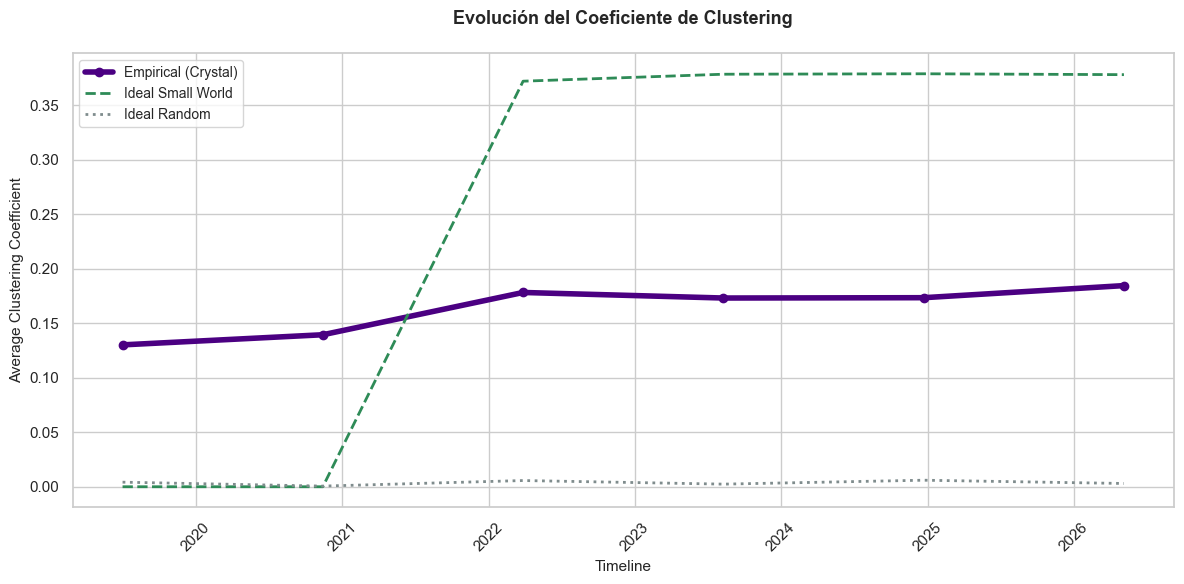

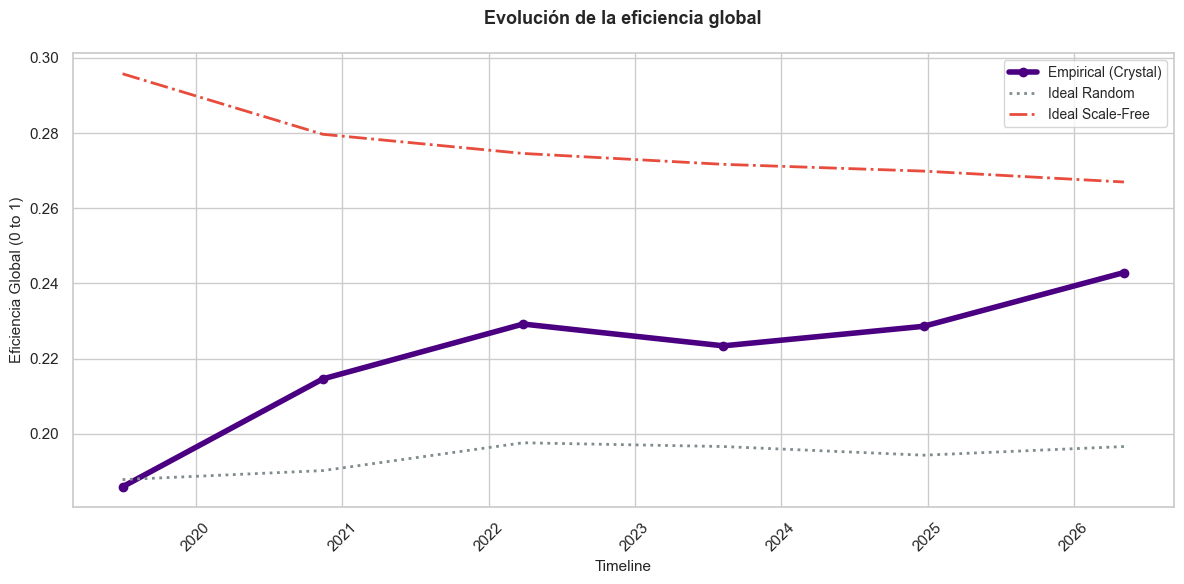

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a clean presentation style for your slides/notebook
sns.set_theme(style="whitegrid")

# Ensure Date is a datetime object for clean timeline plotting
df_topology['Date'] = pd.to_datetime(df_topology['Date'])

# --- Chart 1: Average Clustering Coefficient (C) ---
plt.figure(figsize=(12, 6))

plt.plot(df_topology['Date'], df_topology['Empirical C'], label='Empirical (Crystal)', linewidth=4, color='#4B0082', marker='o')
plt.plot(df_topology['Date'], df_topology['SmallWorld C'], label='Ideal Small World', linestyle='--', linewidth=2, color='#2E8B57')
plt.plot(df_topology['Date'], df_topology['Random C'], label='Ideal Random', linestyle=':', linewidth=2, color='#7F8C8D')

plt.title("Evolución del Coeficiente de Clustering\n", fontsize=13, fontweight='bold')
plt.ylabel("Average Clustering Coefficient", fontsize=11)
plt.xlabel("Timeline", fontsize=11)
plt.legend(fontsize=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- Chart 2: Global Efficiency (E) ---
plt.figure(figsize=(12, 6))

# We look for 'ScaleFree E' or whatever naming variant was appended to the dataframe columns
eff_col = 'ScaleFree E' if 'ScaleFree E' in df_topology.columns else 'ScaleFree L'
emp_eff_col = 'Empirical E' if 'Empirical E' in df_topology.columns else 'Empirical L'
rand_eff_col = 'Random E' if 'Random E' in df_topology.columns else 'Random L'

# Set labels dynamically based on whether you are plotting Length or Efficiency
y_label = "Eficiencia Global (0 to 1)" if "E" in emp_eff_col else "Average Path Length (Hops)"
title_text = "Evolución de la eficiencia global\n" if "E" in emp_eff_col else "Evolution of Average Path Length\n(Lower = navegación más rápida)"

plt.plot(df_topology['Date'], df_topology[emp_eff_col], label='Empirical (Crystal)', linewidth=4, color='#4B0082', marker='o')
plt.plot(df_topology['Date'], df_topology[rand_eff_col], label='Ideal Random', linestyle=':', linewidth=2, color='#7F8C8D')
plt.plot(df_topology['Date'], df_topology[eff_col], label='Ideal Scale-Free', linestyle='-.', linewidth=2, color='#E74C3C')

plt.title(title_text, fontsize=13, fontweight='bold')
plt.ylabel(y_label, fontsize=11)
plt.xlabel("Timeline", fontsize=11)
plt.legend(fontsize=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<>:48: SyntaxWarning: invalid escape sequence '\g'
<>:48: SyntaxWarning: invalid escape sequence '\g'
/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_11176/49781809.py:48: SyntaxWarning: invalid escape sequence '\g'
  ax.plot(log_k, ideal_line, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ideal Fit ($\gamma$ = {-slope:.2f})')


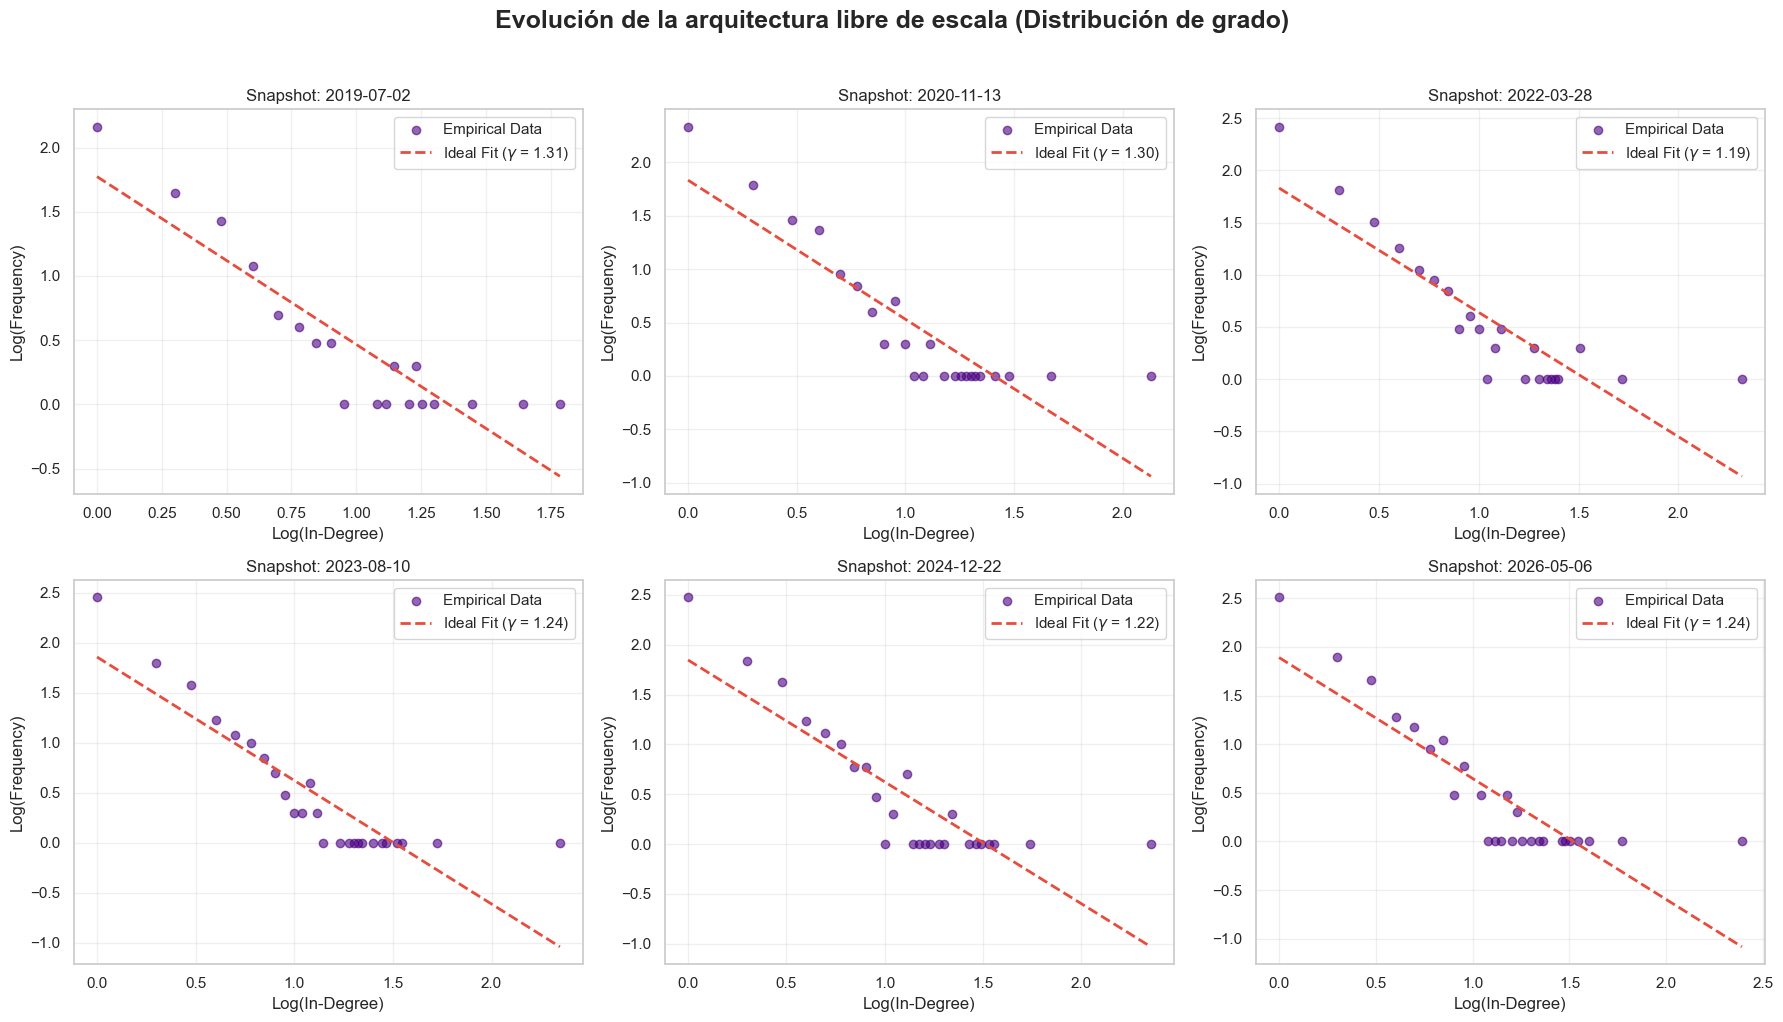

In [25]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path

gold_dir = Path("data/03_gold")

# Re-fetch the 6 target dates so we can pull the raw edges
anchor_date = "2026-05-06"
all_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")
target_dates = all_dates[::-5][::-1] # Grab the 6, and reverse to chronologically order them

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

fig.suptitle("Evolución de la arquitectura libre de escala (Distribución de grado)", fontsize=18, fontweight='bold', y=1.02)

for i, ts in enumerate(target_dates):
    snapshot_key = ts.strftime('%Y-%m-%d')
    edge_file = gold_dir / f"gold_edges_{snapshot_key}.parquet"
    
    if not edge_file.exists():
        continue
        
    edges_df = pd.read_parquet(edge_file)
    G = nx.from_pandas_edgelist(edges_df, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    in_degrees = [d for n, d in G.in_degree() if d > 0]
    
    if len(in_degrees) > 2:
        degree_counts = pd.Series(in_degrees).value_counts().sort_index()
        k = degree_counts.index.values
        P_k = degree_counts.values
        
        # Log transformation
        log_k = np.log10(k)
        log_P_k = np.log10(P_k)
        
        # Calculate ideal slope
        slope, intercept, r_val, _, _ = linregress(log_k, log_P_k)
        ideal_line = (slope * log_k) + intercept
        
        # Plotting
        ax = axes[i]
        ax.scatter(log_k, log_P_k, color='#4B0082', alpha=0.6, label='Empirical Data')
        ax.plot(log_k, ideal_line, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ideal Fit ($\gamma$ = {-slope:.2f})')
        
        ax.set_title(f"Snapshot: {snapshot_key}", fontsize=12)
        ax.set_xlabel("Log(In-Degree)")
        ax.set_ylabel("Log(Frequency)")
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()

# Small worlderness

In [ ]:
# Add Sigma directly to your existing results dataframe
df_topology['Sigma (Small-Worldness)'] = (df_topology['Empirical C'] / df_topology['Random C']) / (df_topology['Empirical L'] / df_topology['Random L'])

print(df_topology[['Date', 'Empirical C', 'Empirical L', 'Sigma (Small-Worldness)']])

diameter = nx.diameter(G_emp)
print(f"Network Diameter: {diameter} hops")

        Date  Empirical C  Empirical L  Sigma (Small-Worldness)
0 2019-07-02       0.1302       4.5653                33.771822
1 2020-11-13       0.1395       4.5653               253.288667
2 2022-03-28       0.1783       4.5653                34.077623
3 2023-08-10       0.1732       4.5653                78.619350
4 2024-12-22       0.1735       4.5653                31.502211
5 2026-05-06       0.1846       4.5653                67.035251
Network Diameter: 11 hops


## Medidas de centralidad a través del tiempo

In [ ]:
import networkx as nx
import pandas as pd

def generate_centrality_comparison_table(graphs_dict, metric='pagerank', top_n=10):
    """
    Generates a Pandas DataFrame comparing the Top N nodes across multiple networks
    based on the specified centrality metric ('pagerank' or 'betweenness').
    """
    table_data = {}
    
    print(f"Calculating {metric.capitalize()} across all networks...")
    
    for graph_name, G in graphs_dict.items():
        if G.number_of_nodes() == 0:
            print(f"Skipping {graph_name}: Graph is empty.")
            continue
            
        # 1. Select and calculate the requested metric
        if metric == 'pagerank':
            scores = nx.pagerank(G, alpha=0.85)
        elif metric == 'betweenness':
            # Note: Betweenness is computationally heavier, might take a few seconds
            scores = nx.betweenness_centrality(G)
        else:
            raise ValueError("Metric must be 'pagerank' or 'betweenness'")
        
        # 2. Sort the nodes by their score in descending order
        sorted_nodes = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        
        # 3. Extract the Top N
        top_list = sorted_nodes[:top_n]
        
        # 4. Format the output cleanly
        formatted_column = [f"{node} ({score:.4f})" for node, score in top_list]
        
        # Handle edge cases where a tiny graph has fewer than N nodes
        while len(formatted_column) < top_n:
            formatted_column.append("-")
            
        table_data[graph_name] = formatted_column

    # 5. Build the final DataFrame
    index_labels = [f"Rank {i+1}" for i in range(top_n)]
    df_comparison = pd.DataFrame(table_data, index=index_labels)
    
    return df_comparison

# --- How to execute both tables ---
my_networks = {
    "Network 2024": G_2024,  # Replace with your actual variable names
    "Network 2025": G_2025,
    "Anchor (2026)": G_std
}

# Generate PageRank Table
df_top10_pr = generate_centrality_comparison_table(my_networks, metric='pagerank', top_n=10)
print("\n--- Top 10 Ecosystem Pillars (PageRank) ---")
print(df_top10_pr.to_string())

# Generate Betweenness Table
df_top10_bw = generate_centrality_comparison_table(my_networks, metric='betweenness', top_n=10)
print("\n--- Top 10 Ecosystem Bridges (Betweenness Centrality) ---")
print(df_top10_bw.to_string())

NameError: name 'G_2024' is not defined